# Sentence Splitting with BiLSTM and BiGRU

In this notebook, we extend our sentence boundary detection system by exploring **recurrent neural models** specifically **BiLSTM** and **BiGRU** on top of our existing feature pipeline.

The goal is to evaluate whether sequential models can better capture context and improve performance, especially for more complex sentence boundary cases.


In [1]:
!git clone https://github.com/anilegin/nlp-sentenceSplitter.git
!cd nlp-sentenceSplitter/
import sys
sys.path.append('/content/nlp-sentenceSplitter')

Cloning into 'nlp-sentenceSplitter'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 135 (delta 37), reused 109 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 10.20 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import classification_report, f1_score

# Import your custom extractors
from utils.featureExtractor import FeatureExtractor
from utils.text_features import TfidfFeatureExtractor
from sklearn.preprocessing import StandardScaler

Since, I validated the best approaches, this time i will merge all the training sets into one.

In [3]:
data_dir = Path("/content/nlp-sentenceSplitter/data/processed")
datasets = ["UD_English-EWT", "UD_English-GUM", "UD_English-ParTUT", "UD_English-PUD"]

train_dfs, dev_dfs, test_dfs = [], [], []

for ds in datasets:
    prefix = ds.replace("UD_English-", "en_").lower()

    train_path = data_dir / ds / f"{prefix}-ud-train.csv"
    dev_path = data_dir / ds / f"{prefix}-ud-dev.csv"
    test_path = data_dir / ds / f"{prefix}-ud-test.csv"

    if train_path.exists(): train_dfs.append(pd.read_csv(train_path))
    if dev_path.exists(): dev_dfs.append(pd.read_csv(dev_path))
    if test_path.exists(): test_dfs.append(pd.read_csv(test_path))

train_df = pd.concat(train_dfs, ignore_index=True)
dev_df = pd.concat(dev_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

y_train = train_df["label"].astype(int)
y_dev = dev_df["label"].astype(int)
y_test = test_df["label"].astype(int)

print(f"Combined Train shape: {train_df.shape}")
print(f"Combined Dev shape: {dev_df.shape}")
print(f"Combined Test shape: {test_df.shape}")

Combined Train shape: (62663, 9)
Combined Dev shape: (9588, 9)
Combined Test shape: (12574, 9)


## Necessary Dataset and Trainer Class

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Extracting numerical features...")
extractor = FeatureExtractor()
X_train_feat = extractor.transform(train_df)
X_dev_feat = extractor.transform(dev_df)
X_test_feat = extractor.transform(test_df)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_feat)
X_dev_num = scaler.transform(X_dev_feat)
X_test_num = scaler.transform(X_test_feat)

print(f"Numerical features shape: {X_train_num.shape}")

Extracting numerical features...
Numerical features shape: (62663, 38)


In [5]:
# defining character Vocabulary
all_text = "".join(train_df["centered_context"].fillna("").values)
chars = sorted(list(set(all_text)))
char2idx = {c: i + 1 for i, c in enumerate(chars)}
char2idx["<UNK>"] = len(char2idx) + 1
vocab_size = len(char2idx) + 1

MAX_LEN = 101 # 50 left + 1 center + 50 right

class SentenceDataset(Dataset):
    def __init__(self, texts, num_features, labels, char2idx, max_len):
        self.texts = texts.fillna("").values
        self.num_features = torch.tensor(num_features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
        self.char2idx = char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        seq = [self.char2idx.get(c, self.char2idx["<UNK>"]) for c in text]
        if len(seq) < self.max_len:
            seq = seq + [0] * (self.max_len - len(seq))
        else:
            seq = seq[:self.max_len]

        return torch.tensor(seq, dtype=torch.long), self.num_features[idx], self.labels[idx]

BATCH_SIZE = 128

train_dataset = SentenceDataset(train_df["centered_context"], X_train_num, y_train, char2idx, MAX_LEN)
dev_dataset = SentenceDataset(dev_df["centered_context"], X_dev_num, y_dev, char2idx, MAX_LEN)
test_dataset = SentenceDataset(test_df["centered_context"], X_test_num, y_test, char2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model, path="best_hybrid_model.pt"):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), path) # Save best weights
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

class CharCNNWithFeatures(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        embed_dim=64,
        num_filters=128,
        kernel_sizes=(3, 5, 7),
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])

        cnn_dim = num_filters * len(kernel_sizes)

        self.num_proj = nn.Sequential(
            nn.Linear(num_numeric_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Sequential(
            nn.Linear(cnn_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_char, x_num):
        emb = self.embedding(x_char)
        emb = emb.transpose(1, 2)

        conv_outs = []
        for conv in self.convs:
            h = torch.relu(conv(emb))
            h = torch.max(h, dim=2).values
            conv_outs.append(h)

        h_char = torch.cat(conv_outs, dim=1)
        h_num = self.num_proj(x_num)

        h = torch.cat([h_char, h_num], dim=1)
        logits = self.head(h).squeeze(1)
        return logits

In [7]:
import statistics
import matplotlib.pyplot as plt

class Trainer():
    """Utility class to train and evaluate a Hybrid Model."""

    def __init__(
        self,
        model,
        loss_function,
        optimizer,
        early_stopper=None
    ):

        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.early_stopper = early_stopper
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def _compute_accuracy_binary(self, predictions, labels):
        # Apply sigmoid because the model outputs raw logits
        probs = torch.sigmoid(predictions)
        discrete_predictions = (probs > 0.5).float()
        return (discrete_predictions.view(-1) == labels.view(-1)).float().mean().item()

    def train(self, train_dataset, valid_dataset, epochs=1):
        assert epochs >= 1 and isinstance(epochs, int)
        print('Training...')

        train_loss = []
        train_accuracy = []
        valid_loss = []
        valid_accuracy = []

        for epoch in range(epochs):
            print(f'\n Epoch {epoch + 1:03d}/{epochs}')

            self.model.train()
            epoch_loss = 0.0
            epoch_accuracy = 0.0

            for step, (x_char, x_num, yb) in enumerate(train_dataset):
                x_char = x_char.to(self.device)
                x_num = x_num.to(self.device)
                yb = yb.to(self.device)

                self.optimizer.zero_grad()
                predictions = self.model(x_char, x_num)

                sample_loss = self.loss_function(predictions, yb)
                sample_loss.backward()
                self.optimizer.step()

                epoch_loss += sample_loss.item()
                epoch_accuracy += self._compute_accuracy_binary(predictions, yb)
                if step % 50 == 0:
                    print(f'    [E: {epoch+1:2d} @ step {step}] current avg loss = {epoch_loss / (step + 1):0.4f}')

            avg_epoch_loss = epoch_loss / len(train_dataset)
            avg_epoch_accuracy = epoch_accuracy / len(train_dataset)

            valid_loss_epoch, valid_accuracy_epoch = self.evaluate(valid_dataset)

            print(f'  [E: {epoch+1:2d}] train loss = {avg_epoch_loss:0.4f} | train accuracy = {avg_epoch_accuracy:0.4f}')
            print(f'  [E: {epoch+1:2d}] valid loss = {valid_loss_epoch:0.4f} | valid accuracy = {valid_accuracy_epoch:0.4f}')

            train_loss.append(avg_epoch_loss)
            train_accuracy.append(avg_epoch_accuracy)
            valid_loss.append(valid_loss_epoch)
            valid_accuracy.append(valid_accuracy_epoch)

            if self.early_stopper:
                self.early_stopper(valid_loss_epoch, self.model, path="best_hybrid_model.pt")
                if self.early_stopper.early_stop:
                    print(f"\nEarly stopping triggered at epoch {epoch+1}! No improvement in validation loss.")
                    break

        print('\n... Done!')

        if self.early_stopper:
            self.model.load_state_dict(torch.load("best_hybrid_model.pt"))
            print("Best model weights restored from Early Stopper.")

        return {
            "avg_epoch_loss": statistics.mean(train_loss),
            "avg_epoch_accuracy": statistics.mean(train_accuracy),
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "valid_loss": valid_loss,
            "valid_accuracy": valid_accuracy
        }

    def evaluate(self, valid_dataset):
        self.model.eval()
        valid_loss = 0.0
        validation_accuracy = 0.0

        with torch.no_grad():
            for x_char, x_num, yb in valid_dataset:
                x_char = x_char.to(self.device)
                x_num = x_num.to(self.device)
                yb = yb.to(self.device)

                predictions = self.model(x_char, x_num)

                sample_loss = self.loss_function(predictions, yb)
                valid_loss += sample_loss.item()
                validation_accuracy += self._compute_accuracy_binary(predictions, yb)

        return valid_loss / len(valid_dataset), validation_accuracy / len(valid_dataset)

## BiLSTM implementation

In [8]:
class BiLSTMWithFeatures(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        embed_dim=64,
        lstm_hidden_dim=128,
        lstm_layers=1,
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.num_proj = nn.Sequential(
            nn.Linear(num_numeric_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # final classifier
        self.head = nn.Sequential(
            nn.Linear((2 * lstm_hidden_dim) + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_char, x_num):
        emb = self.embedding(x_char)

        lstm_out, (h_n, c_n) = self.bilstm(emb)

        # mean pooling over sequence
        h_char = lstm_out.mean(dim=1)

        h_num = self.num_proj(x_num)

        h = torch.cat([h_char, h_num], dim=1)
        logits = self.head(h).squeeze(1)
        return logits

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

bilstm_model = BiLSTMWithFeatures(
    vocab_size=vocab_size,
    num_numeric_features=X_train_num.shape[1],
    embed_dim=64,
    lstm_hidden_dim=128,
    lstm_layers=1,
    hidden_dim=128,
    dropout=0.3
)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

early_stopper = EarlyStopping(patience=4, min_delta=1e-4)

bilstm_trainer = Trainer(
    model=bilstm_model,
    loss_function=loss_function,
    optimizer=optimizer,
    early_stopper=early_stopper
)

bilstm_history = bilstm_trainer.train(
    train_dataset=train_loader,
    valid_dataset=dev_loader,
    epochs=200
)

cuda
Training...

 Epoch 001/200
    [E:  1 @ step 0] current avg loss = 0.6892
    [E:  1 @ step 50] current avg loss = 0.3367
    [E:  1 @ step 100] current avg loss = 0.2714
    [E:  1 @ step 150] current avg loss = 0.2435
    [E:  1 @ step 200] current avg loss = 0.2285
    [E:  1 @ step 250] current avg loss = 0.2166
    [E:  1 @ step 300] current avg loss = 0.2067
    [E:  1 @ step 350] current avg loss = 0.1981
    [E:  1 @ step 400] current avg loss = 0.1900
    [E:  1 @ step 450] current avg loss = 0.1828
  [E:  1] train loss = 0.1790 | train accuracy = 0.9358
  [E:  1] valid loss = 0.1307 | valid accuracy = 0.9580

 Epoch 002/200
    [E:  2 @ step 0] current avg loss = 0.0532
    [E:  2 @ step 50] current avg loss = 0.1258
    [E:  2 @ step 100] current avg loss = 0.1287
    [E:  2 @ step 150] current avg loss = 0.1234
    [E:  2 @ step 200] current avg loss = 0.1225
    [E:  2 @ step 250] current avg loss = 0.1216
    [E:  2 @ step 300] current avg loss = 0.1201
    [E:  2 @

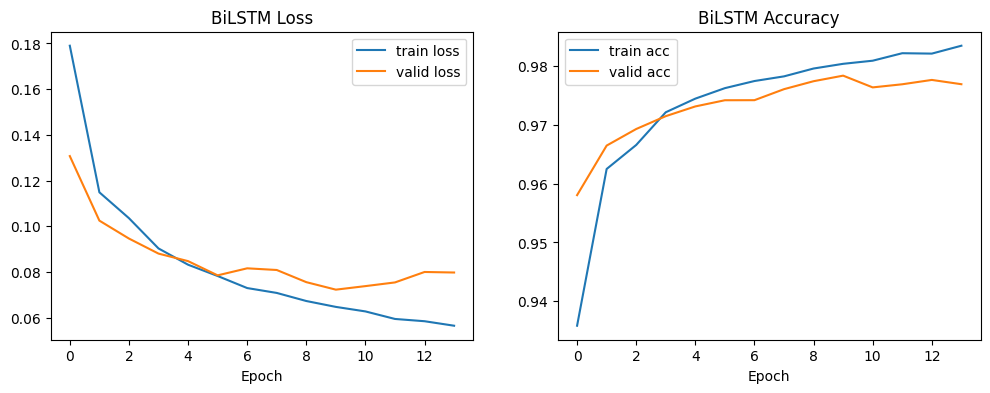

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bilstm_history["train_loss"], label="train loss")
plt.plot(bilstm_history["valid_loss"], label="valid loss")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bilstm_history["train_accuracy"], label="train acc")
plt.plot(bilstm_history["valid_accuracy"], label="valid acc")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

In [12]:
def get_predictions(model, data_loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_char, x_num, yb in data_loader:
            x_char = x_char.to(device)
            x_num = x_num.to(device)

            logits = model(x_char, x_num)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    return np.array(all_probs), np.array(all_preds), np.array(all_labels)

dev_probs, dev_preds, dev_labels = get_predictions(
    bilstm_model,
    dev_loader,
    bilstm_trainer.device
)

print("DEV F1:", f1_score(dev_labels, dev_preds))
print(classification_report(dev_labels, dev_preds, digits=4))

test_probs, test_preds, test_labels = get_predictions(
    bilstm_model,
    test_loader,
    bilstm_trainer.device
)

print("TEST F1:", f1_score(test_labels, test_preds))
print(classification_report(test_labels, test_preds, digits=4))

DEV F1: 0.971133733091619
              precision    recall  f1-score   support

         0.0     0.9744    0.9913    0.9828      5951
         1.0     0.9853    0.9574    0.9711      3637

    accuracy                         0.9784      9588
   macro avg     0.9798    0.9743    0.9769      9588
weighted avg     0.9785    0.9784    0.9783      9588

TEST F1: 0.9746877417928596
              precision    recall  f1-score   support

         0.0     0.9801    0.9915    0.9858      8004
         1.0     0.9848    0.9648    0.9747      4570

    accuracy                         0.9818     12574
   macro avg     0.9825    0.9781    0.9802     12574
weighted avg     0.9818    0.9818    0.9817     12574



## BiGRU implementation

In [13]:
class BiGRUWithFeatures(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        embed_dim=64,
        gru_hidden_dim=128,
        gru_layers=1,
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.bigru = nn.GRU(
            input_size=embed_dim,
            hidden_size=gru_hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_layers > 1 else 0.0
        )

        self.num_proj = nn.Sequential(
            nn.Linear(num_numeric_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.head = nn.Sequential(
            nn.Linear((2 * gru_hidden_dim) + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_char, x_num):
        emb = self.embedding(x_char)

        gru_out, h_n = self.bigru(emb)

        h_char = gru_out.mean(dim=1)

        h_num = self.num_proj(x_num)

        h = torch.cat([h_char, h_num], dim=1)
        logits = self.head(h).squeeze(1)
        return logits

In [15]:
bigru_model = BiGRUWithFeatures(
    vocab_size=vocab_size,
    num_numeric_features=X_train_num.shape[1],
    embed_dim=64,
    gru_hidden_dim=128,
    gru_layers=1,
    hidden_dim=128,
    dropout=0.3
)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    bigru_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

early_stopper = EarlyStopping(patience=4, min_delta=1e-4)

bigru_trainer = Trainer(
    model=bigru_model,
    loss_function=loss_function,
    optimizer=optimizer,
    early_stopper=early_stopper
)

bigru_history = bigru_trainer.train(
    train_dataset=train_loader,
    valid_dataset=dev_loader,
    epochs=50
)

Training...

 Epoch 001/50
    [E:  1 @ step 0] current avg loss = 0.6969
    [E:  1 @ step 50] current avg loss = 0.3333
    [E:  1 @ step 100] current avg loss = 0.2670
    [E:  1 @ step 150] current avg loss = 0.2420
    [E:  1 @ step 200] current avg loss = 0.2253
    [E:  1 @ step 250] current avg loss = 0.2134
    [E:  1 @ step 300] current avg loss = 0.2038
    [E:  1 @ step 350] current avg loss = 0.1943
    [E:  1 @ step 400] current avg loss = 0.1893
    [E:  1 @ step 450] current avg loss = 0.1853
  [E:  1] train loss = 0.1813 | train accuracy = 0.9334
  [E:  1] valid loss = 0.1341 | valid accuracy = 0.9545

 Epoch 002/50
    [E:  2 @ step 0] current avg loss = 0.1300
    [E:  2 @ step 50] current avg loss = 0.1302
    [E:  2 @ step 100] current avg loss = 0.1315
    [E:  2 @ step 150] current avg loss = 0.1279
    [E:  2 @ step 200] current avg loss = 0.1258
    [E:  2 @ step 250] current avg loss = 0.1233
    [E:  2 @ step 300] current avg loss = 0.1238
    [E:  2 @ step 3

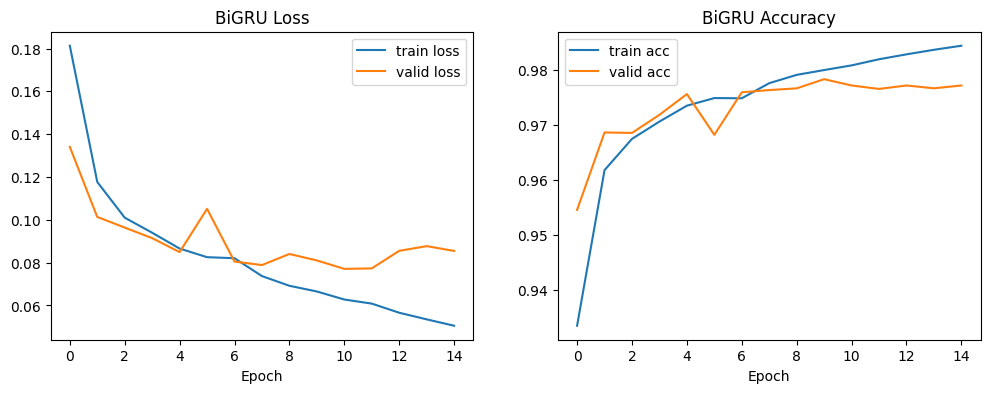

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bigru_history["train_loss"], label="train loss")
plt.plot(bigru_history["valid_loss"], label="valid loss")
plt.title("BiGRU Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bigru_history["train_accuracy"], label="train acc")
plt.plot(bigru_history["valid_accuracy"], label="valid acc")
plt.title("BiGRU Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

In [17]:
dev_probs_bigru, dev_preds_bigru, dev_labels_bigru = get_predictions(
    bigru_model,
    dev_loader,
    bigru_trainer.device
)

print("DEV F1:", f1_score(dev_labels_bigru, dev_preds_bigru))
print(classification_report(dev_labels_bigru, dev_preds_bigru, digits=4))

test_probs_bigru, test_preds_bigru, test_labels_bigru = get_predictions(
    bigru_model,
    test_loader,
    bigru_trainer.device
)

print("TEST F1:", f1_score(test_labels_bigru, test_preds_bigru))
print(classification_report(test_labels_bigru, test_preds_bigru, digits=4))

DEV F1: 0.9695283150132183
              precision    recall  f1-score   support

         0.0     0.9747    0.9889    0.9817      5951
         1.0     0.9814    0.9579    0.9695      3637

    accuracy                         0.9772      9588
   macro avg     0.9780    0.9734    0.9756      9588
weighted avg     0.9772    0.9772    0.9771      9588

TEST F1: 0.9741274909170978
              precision    recall  f1-score   support

         0.0     0.9819    0.9889    0.9854      8004
         1.0     0.9803    0.9681    0.9741      4570

    accuracy                         0.9813     12574
   macro avg     0.9811    0.9785    0.9797     12574
weighted avg     0.9813    0.9813    0.9813     12574



I will check how gru performs on different thresholds

In [19]:
thresholds = np.arange(0.1, 0.91, 0.05)
best_thr = 0.5
best_f1 = -1

for thr in thresholds:
    preds_thr = (dev_probs_bigru > thr).astype(int)
    f1 = f1_score(dev_labels_bigru, preds_thr)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print("Best threshold on dev:", best_thr)
print("Best dev F1:", best_f1)

test_preds_bigru_best = (test_probs_bigru > best_thr).astype(int)

print("TEST F1 with tuned threshold:", f1_score(test_labels_bigru, test_preds_bigru_best))
print(classification_report(test_labels_bigru, test_preds_bigru_best, digits=4))

Best threshold on dev: 0.5500000000000002
Best dev F1: 0.9698744769874477
TEST F1 with tuned threshold: 0.9737480697110081
              precision    recall  f1-score   support

         0.0     0.9807    0.9898    0.9852      8004
         1.0     0.9818    0.9659    0.9737      4570

    accuracy                         0.9811     12574
   macro avg     0.9812    0.9778    0.9795     12574
weighted avg     0.9811    0.9811    0.9810     12574

